<div style="
    border: 2px solid #2c3e50;
    border-radius: 12px;
    padding: 20px;
    background-color: #f8f9fa;
    margin: 10px 0 20px 0;
    box-shadow: 0 2px 8px rgba(0,0,0,0.08);
">

  <h1 style="margin: 0; color: #1f3b73; font-size: 28px;">
    Notebook 07 — Network Optimization
  </h1>

  <h2 style="margin: 10px 0 18px 0; color: #34495e; font-size: 20px; font-weight: normal;">
    Python for Operations Research
  </h2>

  <hr style="border: none; border-top: 1px solid #cfd8dc; margin: 15px 0;">

  <p style="margin: 6px 0; font-size: 16px;">
    <b>Amirkabir University of Technology (Tehran Polytechnic)</b>
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Prof:</b> Dr. A. Golroo
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Mentor:</b> Parsa Sadri
  </p>

</div>


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    0. Problem Definition
  </h2>
</div>

Many real-world optimization problems can be modeled as **networks**.

Examples:

- Transportation systems
- Supply chains
- Internet routing
- Project scheduling
- Power grids
- Social networks

In this notebook we will learn:

1. How to represent networks using Python
2. How to visualize graphs properly
3. Shortest Path algorithms
4. Minimum Spanning Tree
5. Maximum Flow
6. Managerial interpretation of each model


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    1. Creating a Basic Network
  </h2>
</div>

A network consists of:

- Nodes (vertices)
- Edges (connections)

Edges may have:

- Weight (distance, cost, time)
- Capacity (flow limit)
- Direction


## Import Packages

In [79]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

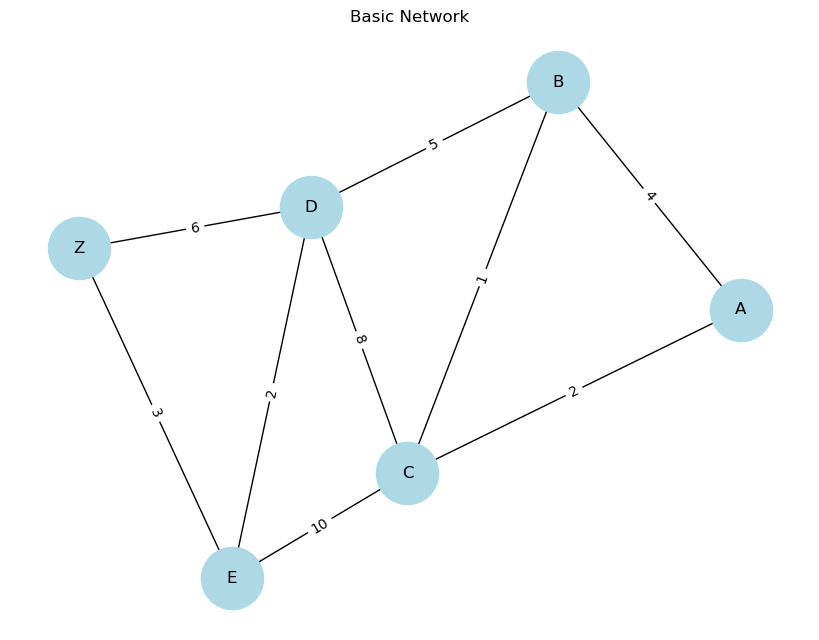

In [80]:
G = nx.Graph()

edges = [
    ('A','B',4),
    ('A','C',2),
    ('B','C',1),
    ('B','D',5),
    ('C','D',8),
    ('C','E',10),
    ('D','E',2),
    ('D','Z',6),
    ('E','Z',3)
]

G.add_weighted_edges_from(edges)
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(8,6))
nx.draw(G,pos,with_labels=True,node_size=2000,node_color='lightblue')

labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

plt.title("Basic Network")
plt.show()

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    2. Shortest Path Problem
  </h2>
</div>

Goal:

Find the minimum-cost path between two nodes.

Applications:

- GPS routing
- Logistics
- Data routing
- Emergency response

Common Algorithms:

- Dijkstra
- Bellman-Ford
- Floyd-Warshall


In [81]:
shortest_path = nx.dijkstra_path(G,'A','Z',weight='weight')
shortest_distance = nx.dijkstra_path_length(G,'A','Z',weight='weight')

print("Shortest Path:", shortest_path)
print("Total Distance:", shortest_distance)

Shortest Path: ['A', 'C', 'B', 'D', 'E', 'Z']
Total Distance: 13


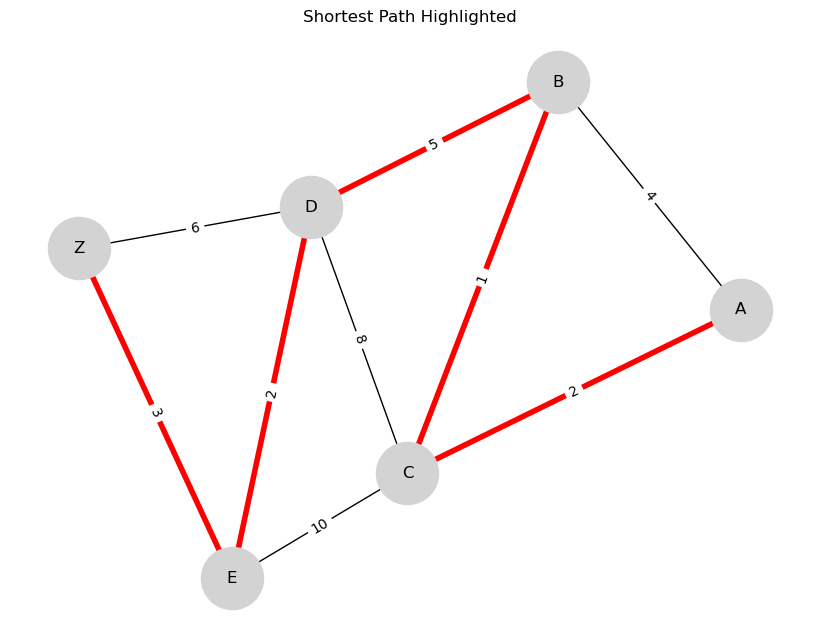

In [82]:
plt.figure(figsize=(8,6))

nx.draw(G,pos,with_labels=True,node_size=2000,node_color='lightgray')
path_edges = list(zip(shortest_path,shortest_path[1:]))
nx.draw_networkx_edges(G,pos,edgelist=path_edges,width=4,edge_color='red')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

plt.title("Shortest Path Highlighted")
plt.show()

Interpretation:

The highlighted path represents the minimum total cost from source to destination.

Managers use this model to reduce transportation cost or time.

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    3. Minimum Spanning Tree (MST)
  </h2>
</div>

Goal:

Connect all nodes with minimum total edge cost.

Applications:

- Network design
- Infrastructure planning
- Electricity grids
- Fiber networks

Common Algorithms:

- Kruskal
- Prim

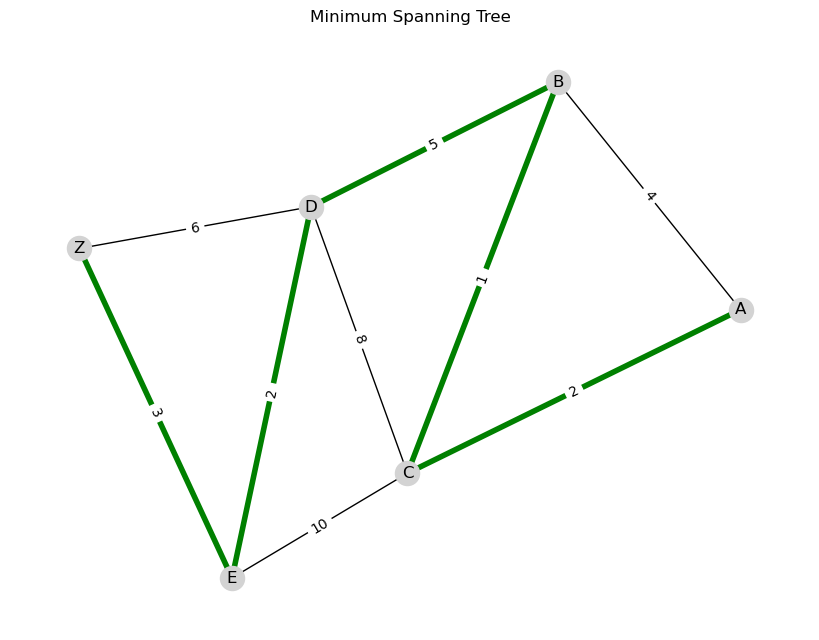

Total MST Cost: 13.0


In [83]:
mst = nx.minimum_spanning_tree(G)

plt.figure(figsize=(8,6))

nx.draw(G,pos,with_labels=True,node_color='lightgray')
nx.draw_networkx_edges(mst,pos,width=4,edge_color='green')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

plt.title("Minimum Spanning Tree")
plt.show()

print("Total MST Cost:", mst.size(weight='weight'))

Interpretation:

MST minimizes infrastructure cost while maintaining connectivity.

It does NOT guarantee shortest path between all pairs.

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    4. Maximum Flow Problem
  </h2>
</div>

Goal:

Maximize flow from a source to a sink.

Applications:

- Supply chain capacity
- Traffic flow
- Communication networks
- Production systems

Common Algorithms:

- Ford-Fulkerson
- Edmonds-Karp


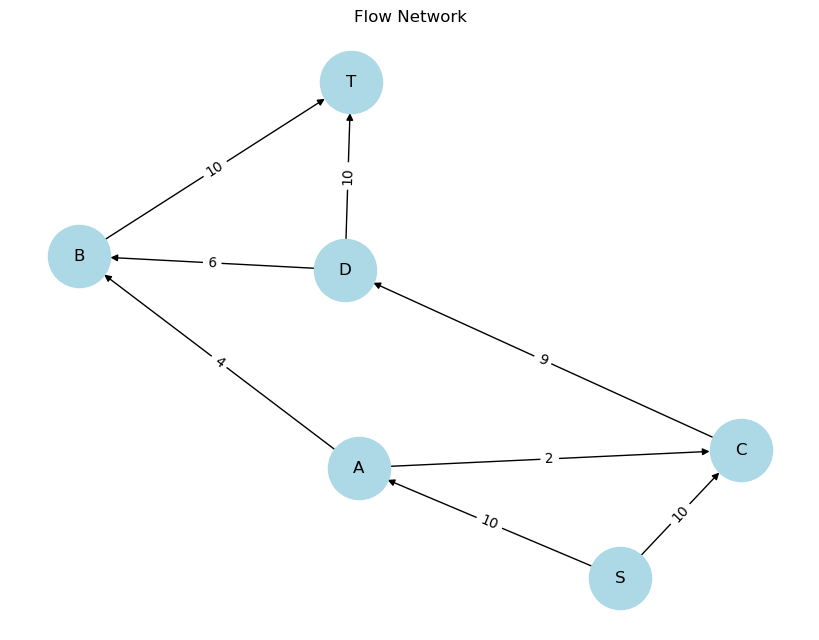

In [84]:
flow_graph = nx.DiGraph()

flow_edges = [
    ('S','A',10),
    ('S','C',10),
    ('A','B',4),
    ('A','C',2),
    ('C','D',9),
    ('B','T',10),
    ('D','B',6),
    ('D','T',10)
]

flow_graph.add_weighted_edges_from(flow_edges,weight='capacity')
pos2 = nx.spring_layout(flow_graph, seed=42)

plt.figure(figsize=(8,6))
nx.draw(flow_graph,pos2,with_labels=True,node_color='lightblue',node_size=2000)

cap_labels = nx.get_edge_attributes(flow_graph,'capacity')
nx.draw_networkx_edge_labels(flow_graph,pos2,edge_labels=cap_labels)

plt.title("Flow Network")
plt.show()

In [85]:
flow_value, flow_dict = nx.maximum_flow(flow_graph,'S','T',capacity='capacity')

print("Maximum Flow:", flow_value)
print("Flow Distribution:")
print(flow_dict)

Maximum Flow: 13
Flow Distribution:
{'S': {'A': 6, 'C': 7}, 'A': {'B': 4, 'C': 2}, 'C': {'D': 9}, 'B': {'T': 4}, 'D': {'B': 0, 'T': 9}, 'T': {}}


Interpretation:

Maximum flow represents the maximum amount of goods (or data) that can move from source to sink.

**The bottleneck edges determine system capacity.**

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    5. Comparing Network Optimization Problems
  </h2>
</div>

| Problem | Objective | Application |
|----------|----------|------------|
| Shortest Path | Minimize distance | Routing |
| Minimum Spanning Tree | Minimize infrastructure cost | Network design |
| Maximum Flow | Maximize throughput | Capacity planning |

Each model answers a different managerial question.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    6. Visualizing Edge Thickness by Weight
  </h2>
</div>

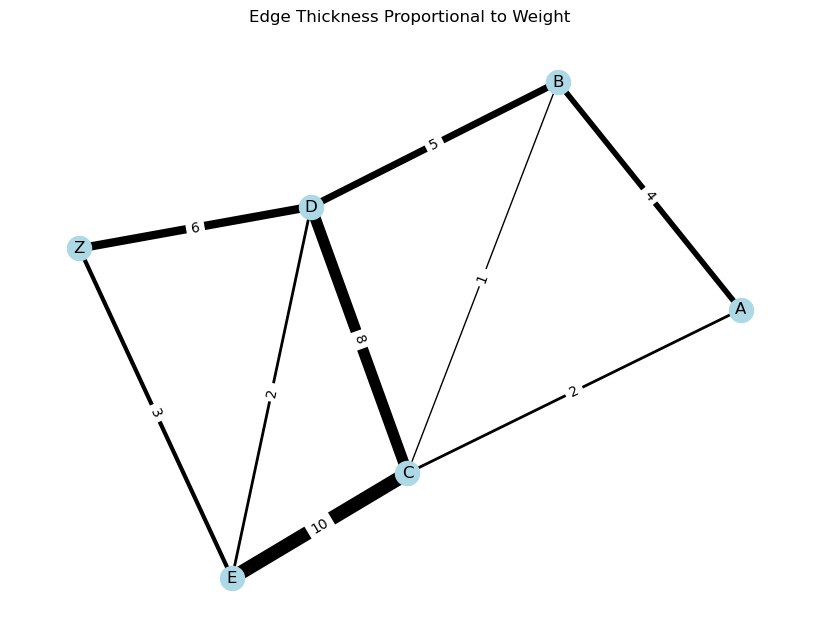

In [86]:
weights = [G[u][v]['weight'] for u,v in G.edges()]
max_weight = max(weights)

widths = [10*(w/max_weight) for w in weights]

plt.figure(figsize=(8,6))
nx.draw(G,pos,with_labels=True,node_color='lightblue',width=widths)
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

plt.title("Edge Thickness Proportional to Weight")
plt.show()

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    7. Large Scale Network Optimization
  </h2>
</div>

In real-world applications, networks can contain **hundreds or thousands of nodes**.

Examples:

- transportation systems
- airline networks
- telecommunication routing
- supply chain networks

For such networks, solving problems **manually becomes impossible**.

In this section we will generate **large networks** and solve them using NetworkX.

We will examine:

1. Large Shortest Path problem
2. Large Minimum Spanning Tree problem
3. Large Maximum Flow problem

The goal is to demonstrate the power of **computational optimization**.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    7.1. Large Shortest Path Example
  </h2>
</div>

Imagine a transportation network with many cities.

Each edge represents:

- road distance
- travel time
- transportation cost

Goal:

Find the cheapest route between two distant cities.


In [87]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

In [88]:
np.random.seed(42)

n_nodes = 40

G = nx.gnm_random_graph(n_nodes,80)

for u,v in G.edges():
    G[u][v]['weight'] = random.randint(1,20)

pos = nx.spring_layout(G,seed=42)

In [89]:
source = 0
target = 35

path = nx.dijkstra_path(G,source,target,weight='weight')
distance = nx.dijkstra_path_length(G,source,target,weight='weight')

print("Shortest path:",path)
print("Total distance:",distance)

Shortest path: [0, 32, 6, 35]
Total distance: 35


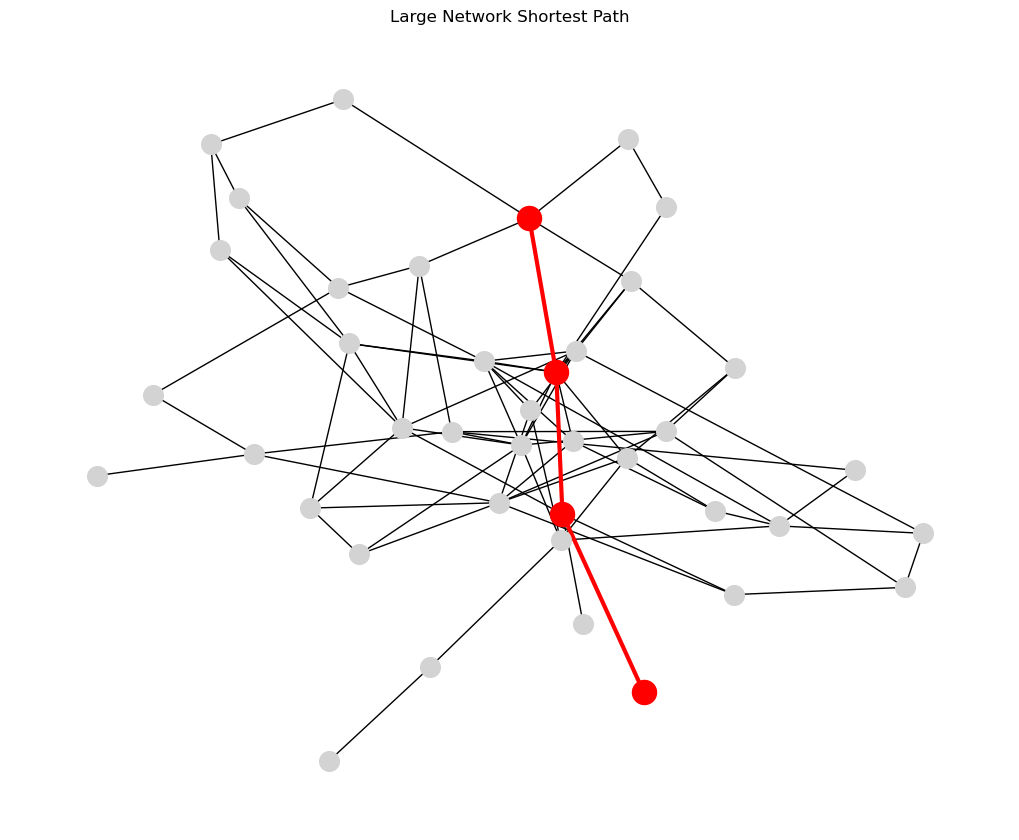

In [90]:
plt.figure(figsize=(10,8))

nx.draw(G,pos,node_size=200,node_color='lightgray')

path_edges = list(zip(path,path[1:]))

nx.draw_networkx_nodes(G,pos,nodelist=path,node_color='red',node_size=300)

nx.draw_networkx_edges(G,pos,edgelist=path_edges,width=3,edge_color='red')

plt.title("Large Network Shortest Path")

plt.show()

Interpretation:

Even with only 40 nodes, the number of possible paths becomes extremely large.

Algorithms like **Dijkstra** efficiently search through the network to find the optimal path.

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    7.2. Large Infrastructure Design Problem
  </h2>
</div>

Suppose a company wants to connect many cities with fiber-optic cables.

Goal:

Connect all cities with **minimum installation cost**.

This is a **Minimum Spanning Tree** problem.

In [91]:
n_nodes = 50

G2 = nx.gnm_random_graph(n_nodes,120)

for u,v in G2.edges():
    G2[u][v]['weight'] = random.randint(5,50)

pos2 = nx.spring_layout(G2,seed=10)

In [92]:
mst = nx.minimum_spanning_tree(G2)
total_cost = mst.size(weight='weight')

print("Total infrastructure cost:",total_cost)

Total infrastructure cost: 801.0


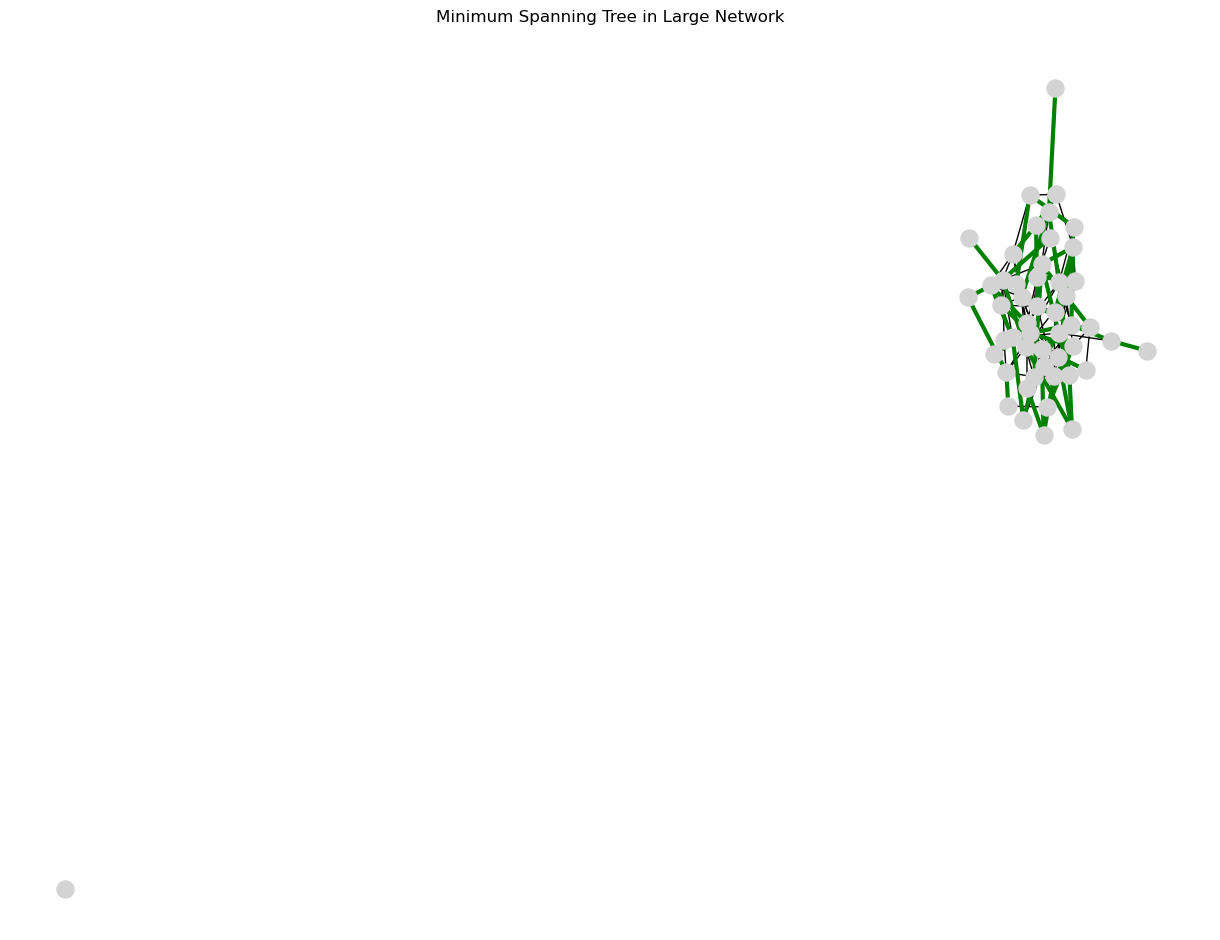

In [93]:
plt.figure(figsize=(12,9))

nx.draw(G2,pos2,node_size=150,node_color='lightgray')

nx.draw_networkx_edges(mst,pos2,width=3,edge_color='green')

plt.title("Minimum Spanning Tree in Large Network")

plt.show()

Interpretation:

The MST selects exactly **n − 1 edges** that connect all nodes.

Without algorithms like **Kruskal or Prim**, evaluating all possible combinations would be computationally infeasible.

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    7.3. Large Supply Chain Flow Problem
  </h2>
</div>

Consider a logistics network:

- source = main warehouse
- sink = retail market

Edges represent transportation routes with capacity limits.

Goal:

Maximize the total amount of goods shipped.

In [94]:
nodes = 30

flow_graph = nx.gnm_random_graph(nodes,70,directed=True)

for u,v in flow_graph.edges():
    flow_graph[u][v]['capacity'] = random.randint(5,30)

source = 0
sink = 29

In [95]:
flow_value,flow_dict = nx.maximum_flow(flow_graph,source,sink,capacity='capacity')

print("Maximum flow from source to sink:",flow_value)

Maximum flow from source to sink: 15


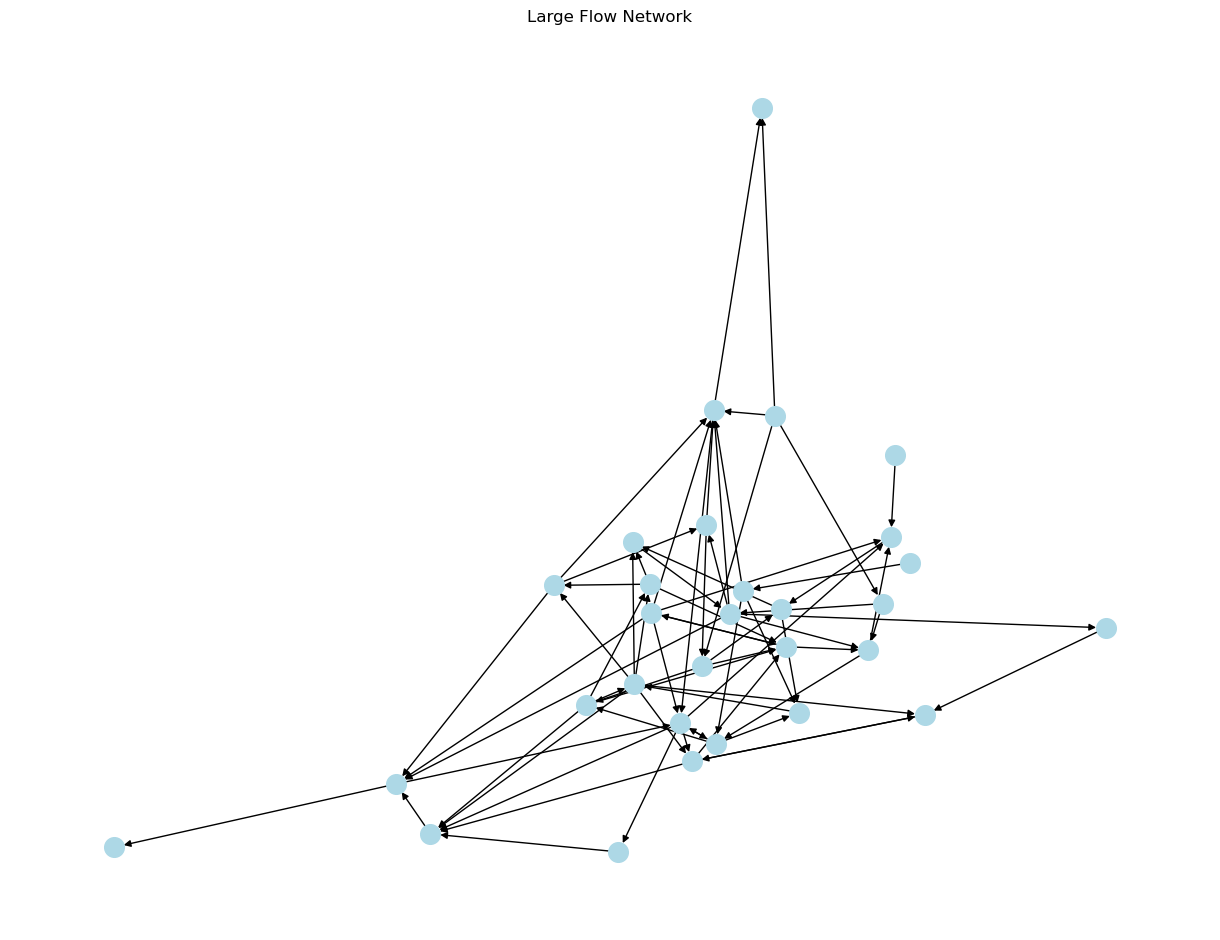

In [96]:
pos3 = nx.spring_layout(flow_graph,seed=20)

plt.figure(figsize=(12,9))

nx.draw(flow_graph,pos3,node_size=200,node_color='lightblue',arrows=True)

plt.title("Large Flow Network")

plt.show()

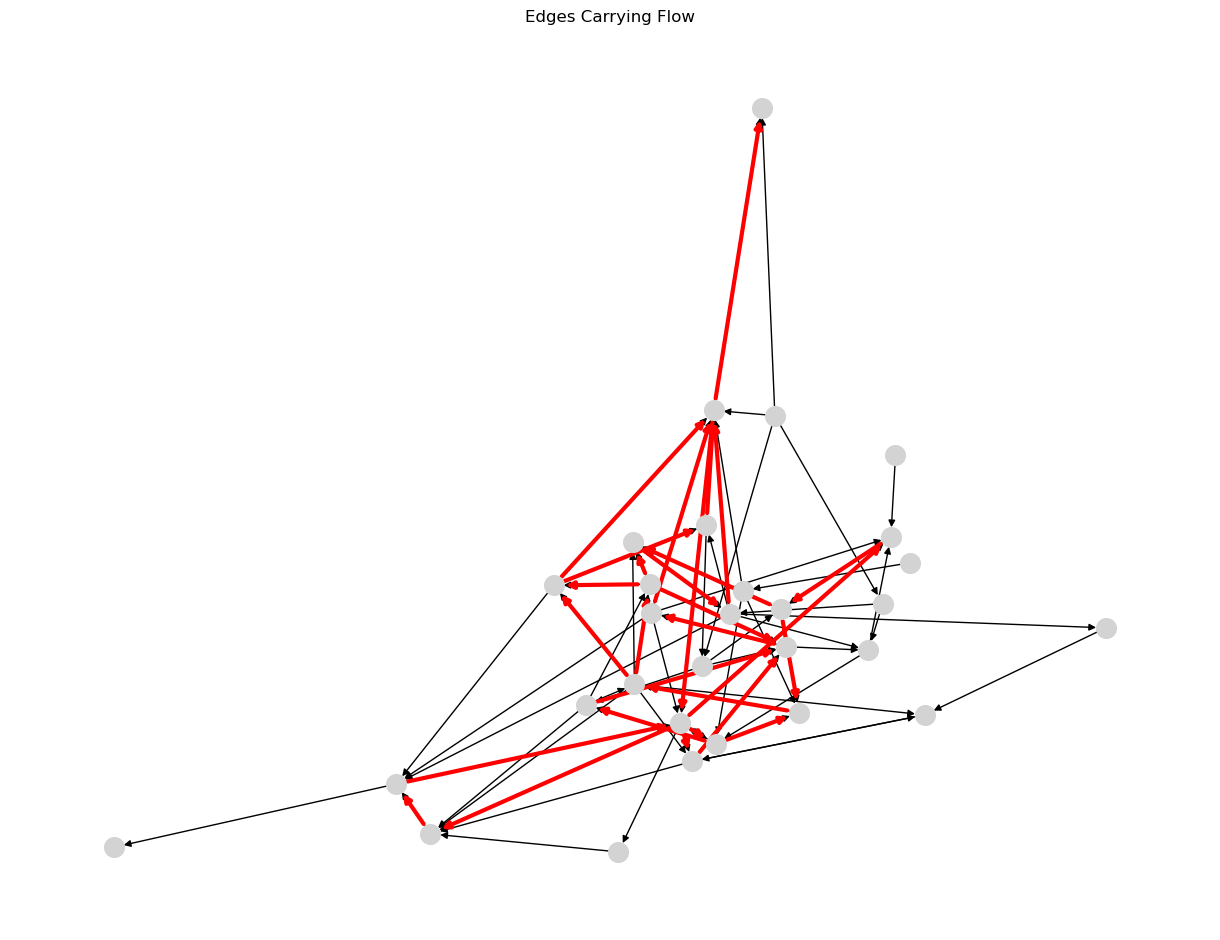

In [97]:
edges_with_flow = []

for u in flow_dict:
    for v in flow_dict[u]:
        if flow_dict[u][v] > 0:
            edges_with_flow.append((u,v))

plt.figure(figsize=(12,9))

nx.draw(flow_graph,pos3,node_size=200,node_color='lightgray')

nx.draw_networkx_edges(flow_graph,pos3,edgelist=edges_with_flow,width=3,edge_color='red')

plt.title("Edges Carrying Flow")

plt.show()

Interpretation:

The highlighted edges represent the routes used in the optimal flow solution.

Some edges remain unused because they are inefficient or constrained by other bottlenecks.

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    7.4. Why Algorithms Matter
  </h2>
</div>

In large networks:

- number of possible paths grows exponentially
- manual calculation becomes impossible
- optimization algorithms efficiently search the solution space

Network algorithms such as:

- Dijkstra
- Kruskal
- Ford-Fulkerson

enable solving problems with **thousands or even millions of nodes**.

This is why computational tools are essential in modern operations research.

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    8. Real-World Network Example
  </h2>
</div>

## Shortest Path on a Real City Map

In this section we will:

1. Download a real road network
2. Select two locations
3. Compute the shortest path
4. Visualize it on a real city map

This demonstrates how network optimization is used in:

- Google Maps / Neshan
- Uber / Snapp / Tapsi
- Delivery systems
- Emergency routing


In [98]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

We download the road network of a real city.

You can change the city name.

In [99]:
# # download graph
# city = "Tehran, Iran"

# G = ox.graph_from_place(city, network_type="drive")

# print("Number of nodes:", len(G.nodes))
# print("Number of edges:", len(G.edges))

In [100]:
# # save graph to disk
# ox.save_graphml(G, "tehran_drive.graphml")

# print("Graph saved successfully")

In [101]:
G = ox.load_graphml("data/tehran_drive.graphml")

print("Number of nodes:", len(G.nodes))
print("Number of edges:", len(G.edges))

Number of nodes: 113866
Number of edges: 227724


Now we choose two real geographic coordinates.

Example:
- Origin: Azadi Square
- Destination: Tajrish

In [102]:
origin_point = (35.6997, 51.3370)   # Azadi Square location
destination_point = (35.8040, 51.4260)  # Tajrish 

origin_node = ox.distance.nearest_nodes(G, origin_point[1], origin_point[0])
destination_node = ox.distance.nearest_nodes(G, destination_point[1], destination_point[0])

We compute shortest path based on distance.

In [103]:
route = nx.shortest_path(G, origin_node, destination_node, weight="length")

route_length = nx.shortest_path_length(G, origin_node, destination_node, weight="length")

print("Route length (meters):", round(route_length,2))
print("Route length (km):", round(route_length/1000,2))

Route length (meters): 17496.83
Route length (km): 17.5


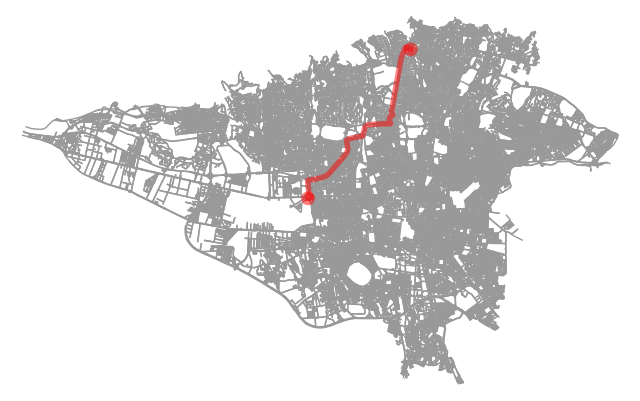

In [104]:
fig, ax = ox.plot_graph_route(G, route, route_color='red', route_linewidth=4, node_size=0, bgcolor='white')

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    7. Exercises
  </h2>
</div>

### Exercise 1
Change edge weights randomly.

Observe how the shortest path changes.

---

### Exercise 2
Add a new node and connect it with random weights.

Recompute the MST.

---

### Exercise 3
Modify capacities in the flow network.

Which edge becomes the bottleneck?

---

### Exercise 4 (Challenge)
Create a random graph with 20 nodes.

Compute:
- Shortest path
- MST
- Network diameter

Visualize the results clearly.
